In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ase
from ase.visualize import view

data = np.load("../EF/data-full.npz", allow_pickle=True)
keys = list(data.keys())
keys
R = data["R"]
P = data["P"]
Z = data["Z"]

In [2]:
from handedness_model import *

In [129]:
def main(args):
  key = jax.random.PRNGKey(args.seed)
  dataset = np.load(args.data, allow_pickle=True)

  train_data, valid_data = prepare_datasets(key, args.num_train, args.num_valid, dataset)
  model = MessagePassingModel(
    features=args.features, 
    max_degree=args.max_degree, 
    num_iterations=args.num_iterations,
     num_basis_functions=args.num_basis_functions, 
     cutoff=args.cutoff,
    include_pseudotensors = args.include_pseudotensors
  )

  params, model, valid_batches = train_model(
    key, model, train_data, valid_data,
     args.num_epochs, 
     args.learning_rate, 
     args.batch_size)
     
  return params, model, valid_batches

In [201]:
results_pt = []

# args = get_args()
import argparse
for PT in [True, False]:
    for L in [0, 1, 2, 3, 4]:
        for it in [0, 1,]:
            args = argparse.Namespace(
                data="handedness.npz",
                features=16,
                max_degree=L,
                num_iterations=it,
                num_basis_functions=16,
                cutoff=12.0,
                num_train=800,
                num_valid=200,
                num_epochs=2,
                learning_rate=1e-3,
                batch_size=1,
                include_pseudotensors=PT,
                seed=42,
            )
            params, model, valid_batches = main(args)
            # print(params)
            
            
            for batch in valid_batches[:36]:
            
                handedness = model.apply(
                  params,
                  atomic_numbers=batch['atomic_numbers'],
                  positions=batch['positions'],
                  dst_idx=batch['dst_idx'],
                  src_idx=batch['src_idx'],
                  batch_segments=batch['batch_segments'],
                  batch_size=1
                )
                results_pt.append({"pred": handedness, "true": batch["handedness"].flatten()[0], 
                                "pt": PT, "L": L, "it": it})

epoch:   1                    train:   valid:
    loss [a.u.]                8.157    1.091
    handedness mae [kcal/mol]      2.228    1.087
epoch:   2                    train:   valid:
    loss [a.u.]                2.557    0.506
    handedness mae [kcal/mol]      1.812    1.000
epoch:   1                    train:   valid:
    loss [a.u.]                0.612    0.499
    handedness mae [kcal/mol]      1.008    0.999
epoch:   2                    train:   valid:
    loss [a.u.]                0.548    0.501
    handedness mae [kcal/mol]      1.009    1.000
epoch:   1                    train:   valid:
    loss [a.u.]                8.157    1.091
    handedness mae [kcal/mol]      2.228    1.087
epoch:   2                    train:   valid:
    loss [a.u.]                2.557    0.506
    handedness mae [kcal/mol]      1.812    1.000
epoch:   1                    train:   valid:
    loss [a.u.]                0.134    0.008
    handedness mae [kcal/mol]      0.260    0.122
epoch:

In [202]:
import pandas as pd
df = pd.DataFrame(results_pt)
df["AE"] = abs(df["pred"] - df["true"])
df["SE"] = df["pred"] - df["true"]
df["SqE"] = (df["pred"] - df["true"])**2

In [230]:
df["byEn"] = df["true"] > 0
df

,pred,true,pt,L,it,AE,SE,SqE,byEn
0,-0.107657954,1.0,True,0,0,1.1076579,-1.1076579,1.2269061,True
1,-0.107657954,-1.0,True,0,0,0.89234203,0.89234203,0.7962743,False
2,-0.107657954,-1.0,True,0,0,0.89234203,0.89234203,0.7962743,False
3,-0.107657954,-1.0,True,0,0,0.89234203,0.89234203,0.7962743,False
4,-0.107657954,1.0,True,0,0,1.1076579,-1.1076579,1.2269061,True
...,...,...,...,...,...,...,...,...,...
715,-0.93803924,-1.0,False,4,1,0.061960757,0.061960757,0.0038391354,False
716,-0.96151704,-1.0,False,4,1,0.038482964,0.038482964,0.0014809385,False
717,0.98891103,1.0,False,4,1,0.011088967,-0.011088967,0.0001229652,True
718,-0.90586466,-1.0,False,4,1,0.094135344,0.094135344,0.008861463,False


In [233]:
_ = df[df["it"] > 0]
_= _.groupby(["L", "pt", "byEn"]).mean()
_=_[["SE"]]

_.style.background_gradient(cmap="RdBu", subset=["AE", "SE"], vmin=-1, vmax=1)
# _.style.background_gradient(cmap="Reds", subset=["pt"])
table = (
    # df.groupby(["L", "it", "pt", "byEn"])
      # .mean()
      _.unstack("L")
)
table
print(table.style.background_gradient(cmap="RdBu", subset=[ "SE"], vmin=-1, vmax=1).to_latex(
        convert_css=True,
    hrules=True
))


\begin{tabular}{lllllll}
\toprule
 &  & \multicolumn{5}{r}{SE} \\
 & L & 0 & 1 & 2 & 3 & 4 \\
pt & byEn &  &  &  &  &  \\
\midrule
\multirow[c]{2}{*}{False} & False & {\cellcolor[HTML]{0E4179}} \color[HTML]{F1F1F1} 0.931351 & {\cellcolor[HTML]{F6AF8E}} \color[HTML]{000000} -0.366494 & {\cellcolor[HTML]{F2F5F6}} \color[HTML]{000000} 0.026897 & {\cellcolor[HTML]{F9C4A9}} \color[HTML]{000000} -0.284890 & {\cellcolor[HTML]{ECF2F5}} \color[HTML]{000000} 0.060435 \\
 & True & {\cellcolor[HTML]{67001F}} \color[HTML]{F1F1F1} -1.066565 & {\cellcolor[HTML]{FAE8DE}} \color[HTML]{000000} -0.102397 & {\cellcolor[HTML]{FAEAE1}} \color[HTML]{000000} -0.090841 & {\cellcolor[HTML]{F6B191}} \color[HTML]{000000} -0.358572 & {\cellcolor[HTML]{F8F4F2}} \color[HTML]{000000} -0.022986 \\
\multirow[c]{2}{*}{True} & False & {\cellcolor[HTML]{0D3F76}} \color[HTML]{F1F1F1} 0.938686 & {\cellcolor[HTML]{FBE4D6}} \color[HTML]{000000} -0.136426 & {\cellcolor[HTML]{E0ECF3}} \color[HTML]{000000} 0.118108 & {\cellcolor

(-2.0, 2.0)

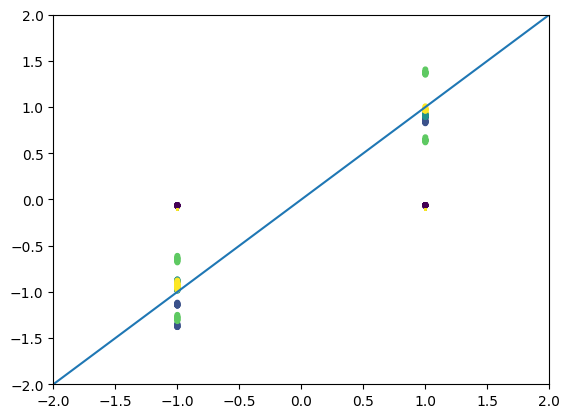

In [207]:
plt.scatter(df["true"], df["pred"], c=df["L"], s=df["it"]*10 + 0.5)
ax = plt.gca()
plt.plot([0,1], [0,1], transform=ax.transAxes)
plt.xlim(-2,2)
plt.ylim(-2,2)
# plt.legend()

In [25]:
# params

In [41]:
try:
    from scipy.spatial import cKDTree
    _HAS_SCIPY = True
except Exception:
    _HAS_SCIPY = False


def oriented_volume(p1, p2, p3, p4):
    """
    Oriented (signed) volume of tetrahedron (p1, p2, p3, p4).
    Returns OV = (1/6) * (p1-p4) · ((p2-p4) × (p3-p4))
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)
    p4 = np.asarray(p4, dtype=float)

    a = p1 - p4
    b = p2 - p4
    c = p3 - p4

    return (1.0 / 6.0) * np.dot(a, np.cross(b, c))


def oriented_volume_det(p1, p2, p3, p4):
    """
    Same OV computed via the 4x4 determinant:
    OV = (1/6) * det([[1,1,1,1],
                     [x1,x2,x3,x4],
                     [y1,y2,y3,y4],
                     [z1,z2,z3,z4]])
    """
    p1 = np.asarray(p1, dtype=float)
    p2 = np.asarray(p2, dtype=float)
    p3 = np.asarray(p3, dtype=float)
    p4 = np.asarray(p4, dtype=float)

    M = np.array([
        [1,     1,     1,     1],
        [p1[0], p2[0], p3[0], p4[0]],
        [p1[1], p2[1], p3[1], p4[1]],
        [p1[2], p2[2], p3[2], p4[2]],
    ], dtype=float)

    return (1.0 / 6.0) * np.linalg.det(M)


def four_nearest_neighbors(positions, k=4):
    """
    Returns (neighbors, distances)
      neighbors: (N, k) int indices of k nearest atoms for each atom (excluding itself)
      distances: (N, k) float distances corresponding to neighbors
    """
    pos = np.asarray(positions, dtype=float)
    n = pos.shape[0]
    if pos.shape[1] != 3:
        raise ValueError("positions must be shape (N, 3)")

    if _HAS_SCIPY:
        tree = cKDTree(pos)
        # query k+1 because the closest is the atom itself at distance 0
        dists, idxs = tree.query(pos, k=k + 1)
        dists = dists[:, 1:]
        idxs = idxs[:, 1:]
        return idxs, dists

    # Fallback O(N^2): OK for small N
    diffs = pos[:, None, :] - pos[None, :, :]
    dmat = np.linalg.norm(diffs, axis=2)
    np.fill_diagonal(dmat, np.inf)
    idxs = np.argsort(dmat, axis=1)[:, :k]
    dists = np.take_along_axis(dmat, idxs, axis=1)
    return idxs, dists

In [32]:
R[0], Z[0]

(array([[[-0.856624, 0.129623, 1.934218],
         [-1.113226, 0.208861, 0.29253],
         [-2.395473, -0.129327, -0.244816],
         [-2.758218, 0.292541, -1.608939],
         [-3.369716, -0.937218, 0.535769],
         [0.00851, 0.750542, -0.561608],
         [0.074188, 2.289299, -0.495448],
         [1.530449, 2.646581, -0.349334],
         [2.25431, 1.399645, 0.131496],
         [1.32012, 0.278177, -0.140145],
         [1.720577, -1.093701, -0.088373],
         [0.86284, -2.237621, -0.873717],
         [3.046157, -1.479629, 0.505688],
         [-3.842935, 0.16159, -1.799584],
         [-2.564452, 1.387345, -1.717807],
         [-2.178615, -0.257288, -2.347192],
         [-2.88315, -1.865078, 0.871457],
         [-4.253185, -1.197732, -0.071191],
         [-3.687413, -0.336486, 1.41572],
         [-0.110561, 0.468629, -1.607865],
         [-0.39813, 2.77545, -1.388399],
         [-0.48387, 2.673344, 0.418778],
         [1.943412, 2.942095, -1.384198],
         [1.714216, 3.502091, 

In [37]:
index = 0
atoms = ase.Atoms( Z[index], R[index][0])

In [38]:
view(atoms, viewer="x3d")

In [9]:
handedness = np.tile(np.array([1, -1,]), len(R)//2)

In [10]:
handedness

array([ 1, -1,  1, ..., -1,  1, -1], shape=(10000,))

In [11]:
out_data = {"R": R, "Z": Z, "handedness": handedness}
np.savez("handedness.npz", **out_data)

In [42]:
four_nearest_neighbors(R[0][0])

(array([[ 1,  2,  5, 18],
        [ 2,  5,  0, 19],
        [ 1,  3,  4, 18],
        [15, 13, 14,  2],
        [16, 17, 18,  2],
        [19,  9,  1,  6],
        [20, 21,  7,  5],
        [23, 22,  6,  8],
        [24, 25,  9,  7],
        [10,  5,  8, 19],
        [ 9, 12, 11, 27],
        [10,  9, 12, 27],
        [27, 26, 28, 10],
        [ 3, 14, 15,  2],
        [ 3, 13, 15,  2],
        [ 3, 13, 14,  2],
        [ 4, 17, 18,  2],
        [ 4, 16, 18,  2],
        [ 4, 17, 16,  2],
        [ 5,  9,  6,  1],
        [ 6, 21,  7,  5],
        [ 6, 20,  7,  5],
        [ 7, 23,  6,  8],
        [ 7, 22,  8,  6],
        [ 8, 25,  9,  7],
        [ 8, 24,  9,  7],
        [12, 27, 28, 10],
        [12, 26, 28, 10],
        [12, 27, 26, 10]]),
 array([[1.66350916, 2.680168  , 2.7135115 , 2.91538405],
        [1.43082816, 1.51038461, 1.66350916, 2.16432846],
        [1.43082816, 1.47322371, 1.48699369, 2.11409641],
        [1.08778171, 1.10910083, 1.11713621, 1.47322371],
        [1.1

In [47]:
R_ = R[index][0]
Z_ = Z[index]
neighbours, distances = four_nearest_neighbors(R_)

for z, ns in zip(Z_, neighbours):
    _ = R_[ns]
    print(z, oriented_volume_det(*_))

16 -0.15348372815114586
6 0.3569074532518456
7 0.8881474898788633
6 -0.8616158217092682
6 0.8714416408484467
6 -1.3752966107669127
6 -1.1690450446152185
6 -1.1665203033996052
6 -1.1331980804176531
7 0.8787347137812944
6 -0.3889655039297366
16 -0.10018200954874674
6 0.8889750687327254
1 -0.2265940998064958
1 0.21643364214764005
1 -0.23984477429768597
1 0.23243734446680256
1 -0.237004865555278
1 -0.22861339448205792
1 0.42415123040820224
1 -0.35102286470379596
1 0.32119071853776976
1 0.31495659929353187
1 0.3528879100705822
1 -0.341740552711906
1 0.3224028779881818
1 -0.23655521845327382
1 0.23408128364147351
1 0.23652367658435325


In [51]:
R_ = R[index+1][0]
Z_ = Z[index]
neighbours, distances = four_nearest_neighbors(R_)

for z, ns in zip(Z_, neighbours):
    _ = R_[ns]
    print(z, oriented_volume_det(*_))

16 0.17674344042208723
6 -0.3706639277797472
7 -0.8856681470252097
6 -0.8656042012772157
6 -0.8738198330784479
6 -1.3708615933994803
6 -1.1461982350528186
6 1.1298674788675926
6 1.1098496226250136
7 0.8908409848367527
6 0.6474504466973592
16 0.10194360721734158
6 0.90314866218864
1 0.22902661788819778
1 0.23216060984197265
1 -0.2293628722644714
1 -0.22738063715458962
1 -0.22662811430824037
1 0.2356690897676536
1 -0.42759431742441373
1 -0.3344999942127853
1 -0.32526764857614565
1 0.3201753684600069
1 -0.3408498414115759
1 -0.32008769105785134
1 0.3369138814072905
1 0.233982303605524
1 -0.2450854262515647
1 -0.2414248952722624
